### Imports

In [21]:
import numpy as np
import scipy  
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

### Let's also generate some fake data.

In [41]:
import importlib
import fake_data as fd
importlib.reload(fd)

fd.generate_all("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data")

Wrote 20 bias frames to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_A_bias/
Wrote 9 cooler-off dark frames to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_C_dark_off/
Wrote 9 cooler-on dark frames to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_C_dark_on/
Wrote 13 linearity frames to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_B_linearity/
Wrote 10 PTC flat frames to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_D_ptc/
Wrote 24 cosmic-ray darks + 3 stray bias + 1 stray short dark to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_E_cosmic_rays/

Ground truth used for all of the above:
    shape: (200, 200)
    bias_level: 1000.0
    read_noise_dn: 8.0
    gain: 2.5
    dark_rate_cooler_off_dn_s: 8.0
    dark_rate_cooler_on_dn_s: 0.5
    n_h

### A. Measuring the Bias and Read Noise

Bias level (mean of means): 999.9908506141662
Read noise (mean of stds): 8.005424927217948
Std of means (frame-to-frame bias stability): 0.036195378219286554
Std of stds (frame-to-frame noise consistency): 0.02794679884413529


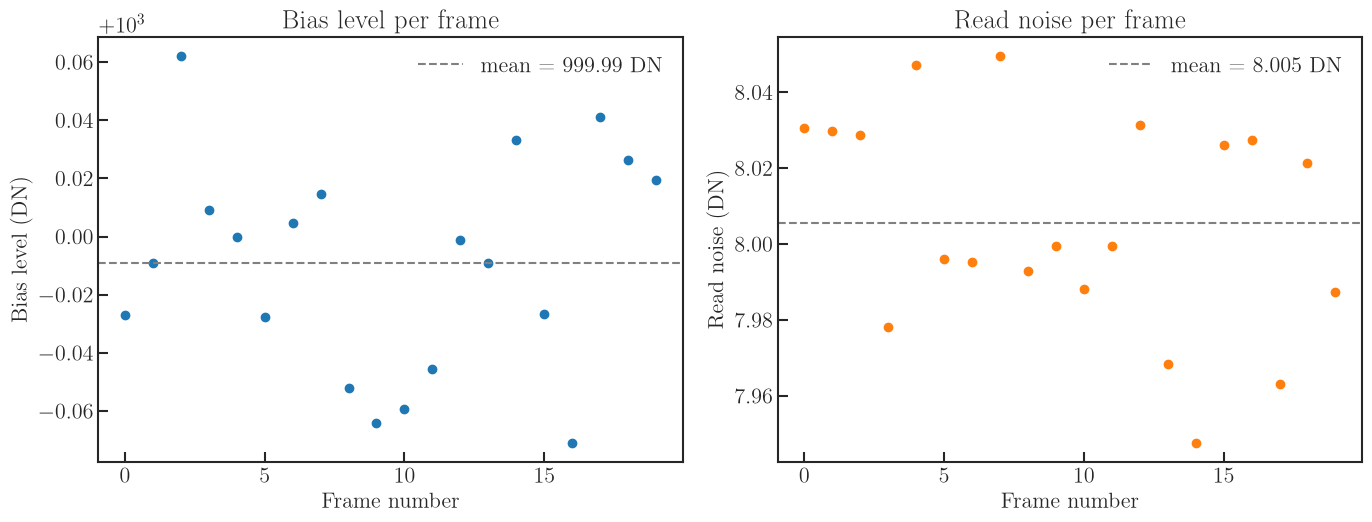

In [80]:
import importlib
import bias_and_read_noise as brn
importlib.reload(brn)

brn.compute_bias_and_read_noise("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_A_bias")

### B. Linearity and Saturation

Loaded 13 frames, exposure times (s): [5.0e-02 1.0e-01 5.0e-01 1.0e+00 2.0e+00 5.0e+00 1.0e+01 2.0e+01 3.0e+01
 4.5e+01 6.0e+01 8.0e+01 1.0e+02]
Centroid: (99.55, 99.54)
Linear fit (using 10 points): signal = 11768.96 * exptime + 82.67

 exptime (s)    peak (DN)    aperture sum (DN)         flag
       0.050       1131.6                454.7    short-exp
       0.100       1157.2               1922.7             
       0.500       1339.2               5199.5             
       1.000       1704.0              13032.8             
       2.000       2329.6              23559.4             
       5.000       4311.5              58784.4             
      10.000       7523.3             116972.3             
      20.000      14073.4             235715.0             
      30.000      20435.8             352131.6             
      45.000      29955.6             530230.4             
      60.000      40000.2             706370.8             
      80.000      53106.3             94250

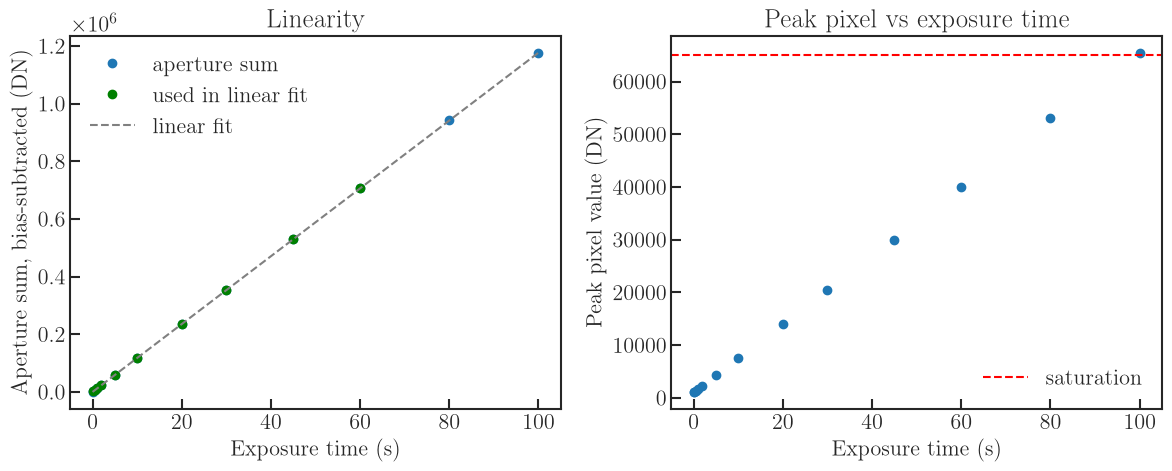

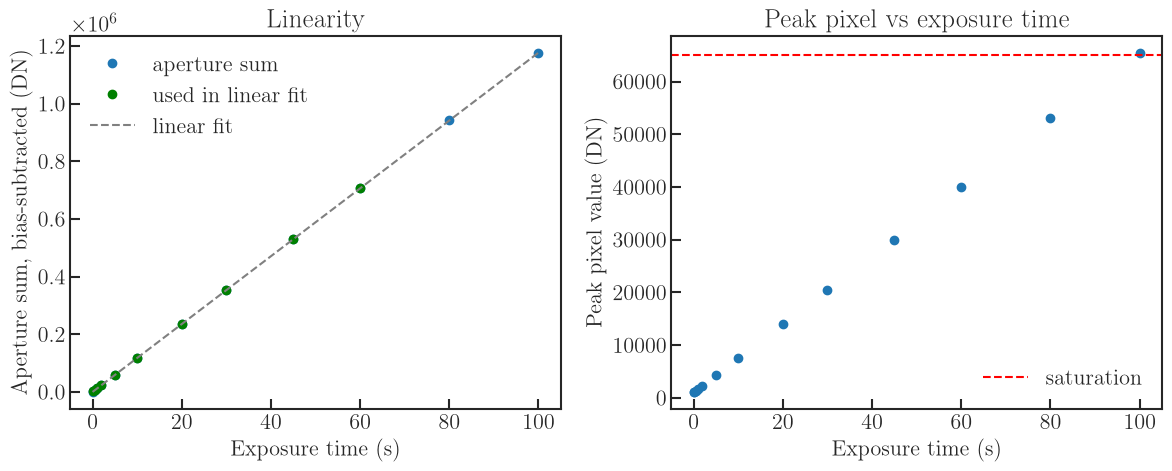

In [53]:
import importlib
import linearity_and_saturation as ls
importlib.reload(ls)

results = ls.analyze_linearity("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_B_linearity")
ls.plot_linearity(results)

### C. Dark Current

Loaded 9 frames, exposure times (s): [1.0e-01 1.0e+00 5.0e+00 1.0e+01 2.0e+01 4.0e+01 8.0e+01 1.6e+02 3.2e+02]

Single pixel (100, 100): slope = 8.0074 DN/s, intercept = 989.1 DN
Region median: slope = 8.0000 DN/s, intercept = 1000.0 DN
Loaded 9 frames, exposure times (s): [1.0e-01 1.0e+00 5.0e+00 1.0e+01 2.0e+01 4.0e+01 8.0e+01 1.6e+02 3.2e+02]

Single pixel (100, 100): slope = 0.5184 DN/s, intercept = 1013.4 DN
Region median: slope = 0.4998 DN/s, intercept = 999.9 DN


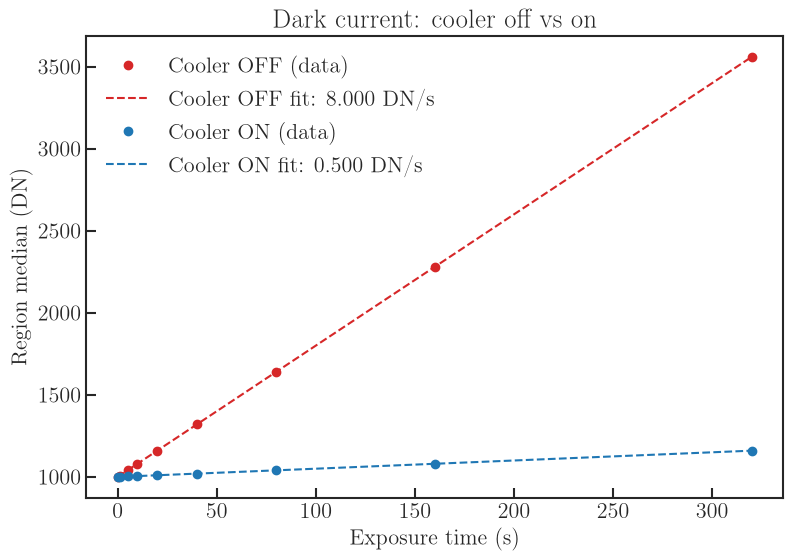

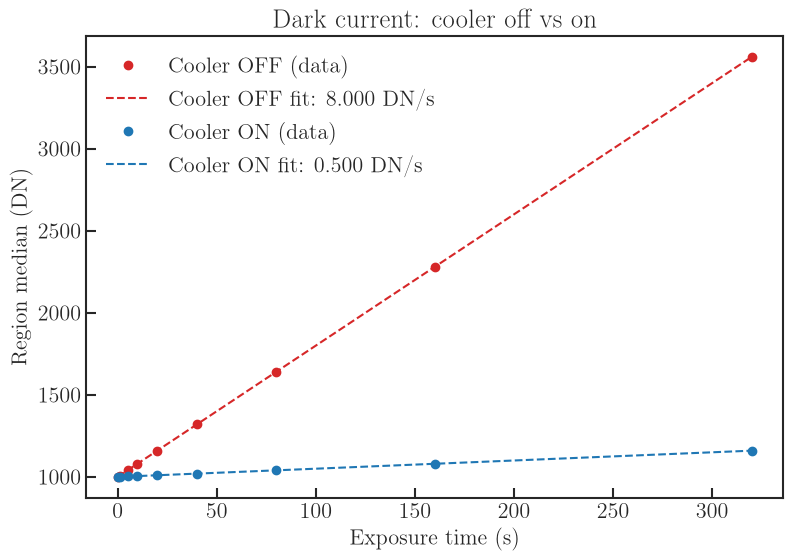

In [57]:
import importlib
import dark_current as dc
importlib.reload(dc)

off_results = dc.analyze_dark_current("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_C_dark_off")
on_results = dc.analyze_dark_current("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_C_dark_on")

dc.plot_comparison(off_results, on_results)

### D. DN-to-electrons

Loaded 10 frames, exposure times (s): [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

 exptime (s)    signal (DN)   noise (DN)  shot noise (DN)           regime
       1.000            5.1         8.70             3.41 read noise floor
       2.000           15.0        10.00             5.99       shot noise
       3.000           50.0        13.68            11.10       shot noise
       4.000          150.0        21.26            19.70       shot noise
       5.000          399.7        33.37            32.40       shot noise
       6.000         1000.8        55.67            55.09       shot noise
       7.000         3000.1       106.47           106.17    fixed pattern
       8.000         8000.2       212.26           212.11    fixed pattern
       9.000        20003.2       460.44           460.37    fixed pattern
      10.000        45007.1       957.30           957.27    fixed pattern

Fitted gain G = 2.5582 DN/electron
Read noise in electrons: 20.48 e-
Fixed pattern noise frac

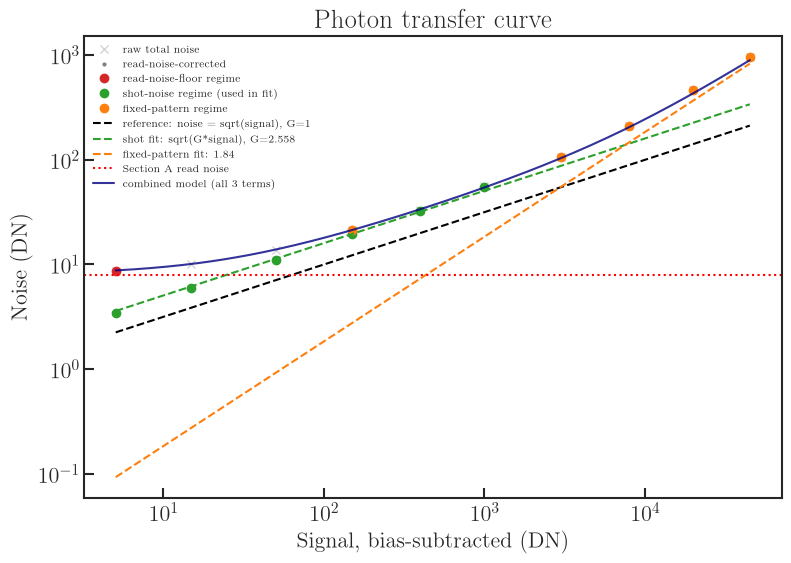

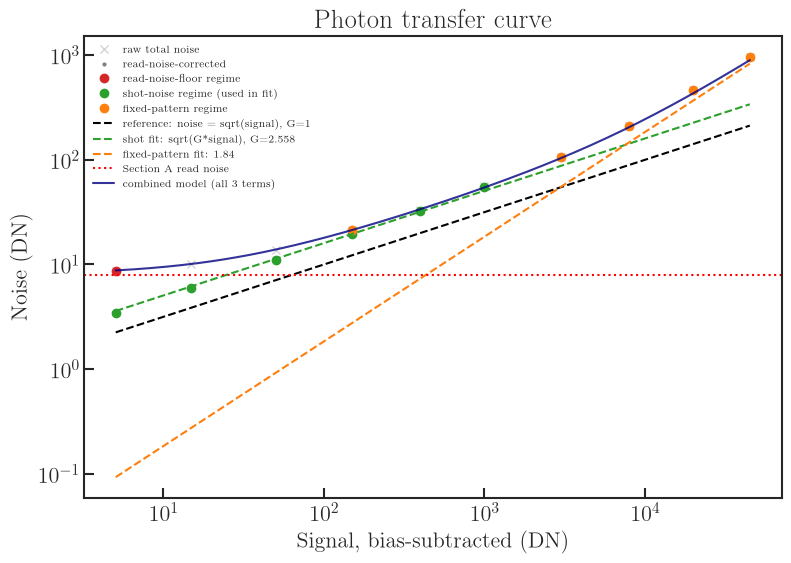

In [61]:
import importlib
import photon_transfer as pt
importlib.reload(pt)

results = pt.analyze_photon_transfer(
    "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data/section_D_ptc",
    bias_level=999.9908506141662,         # from Section A 
    read_noise_dn=8.005424927217948,      # from Section A 
)
pt.plot_ptc(results)

### E. Cosmic Rays

CCD profile: andor  (pixel pitch = 13.5 um, exptime = 600.0 s)

Loaded 19 frames from /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays/, shape (19, 512, 2048)
Median map level: 159.0 DN, robust sigma: 1.48 DN, threshold: 166.4 DN
Hot pixels found: 107
Residual robust sigma: 5.93 DN, cosmic-ray threshold: 29.7 DN
Cosmic ray candidates per frame: [    102      89 1048469      96      73     146      83     110      82
     116     155     105      92     147      83      68      76     205
      98]

*** 1 BAD FRAME(S) DETECTED (>1.0% of pixels flagged -- not real cosmic ray statistics, likely light leak / saturation / corruption): ***
    frame index 2: 1048469 pixels (100.0% of frame) -- excluded from rate
    -> Inspect these frames directly (e.g. plt.imshow) before trusting the rate below.

Good frames used for rate: 18 / 19
Mean events/frame (good frames only): 107.00
Bad frame file paths:
    [2] /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 

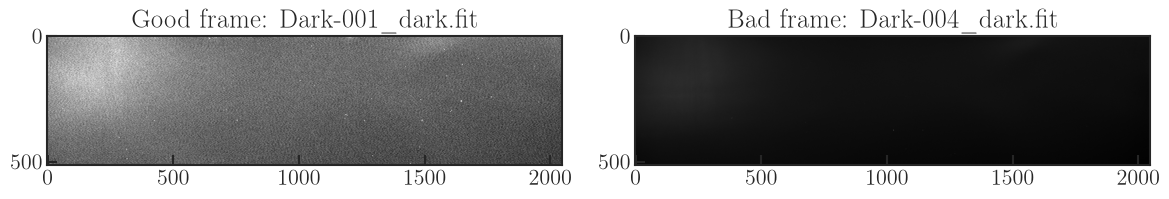

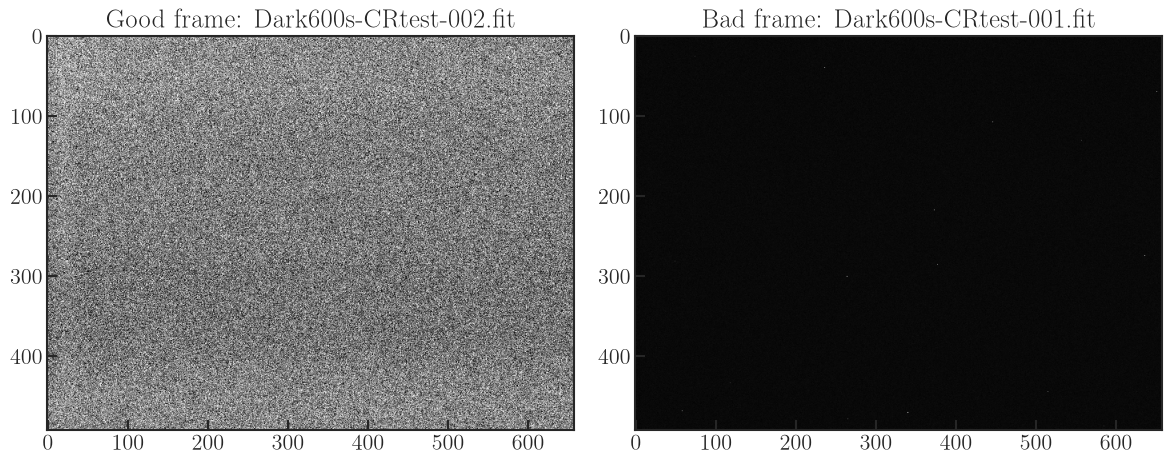

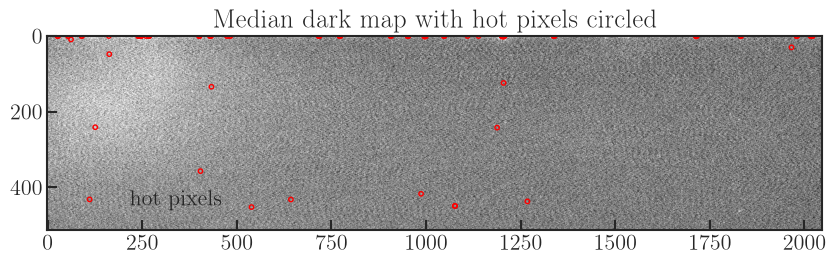

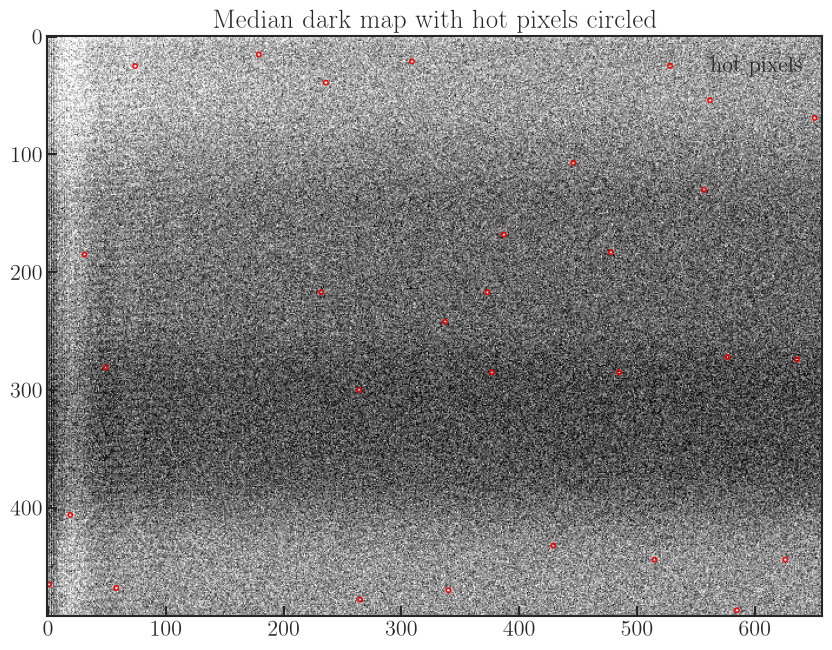

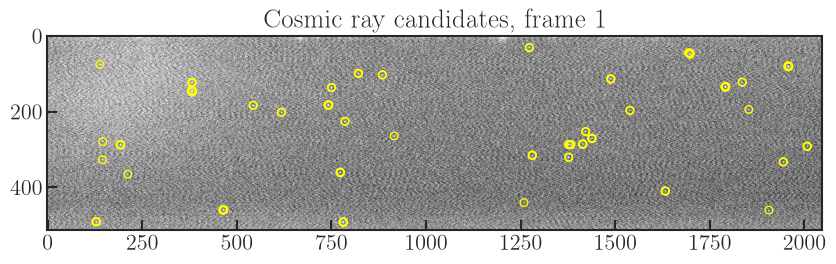

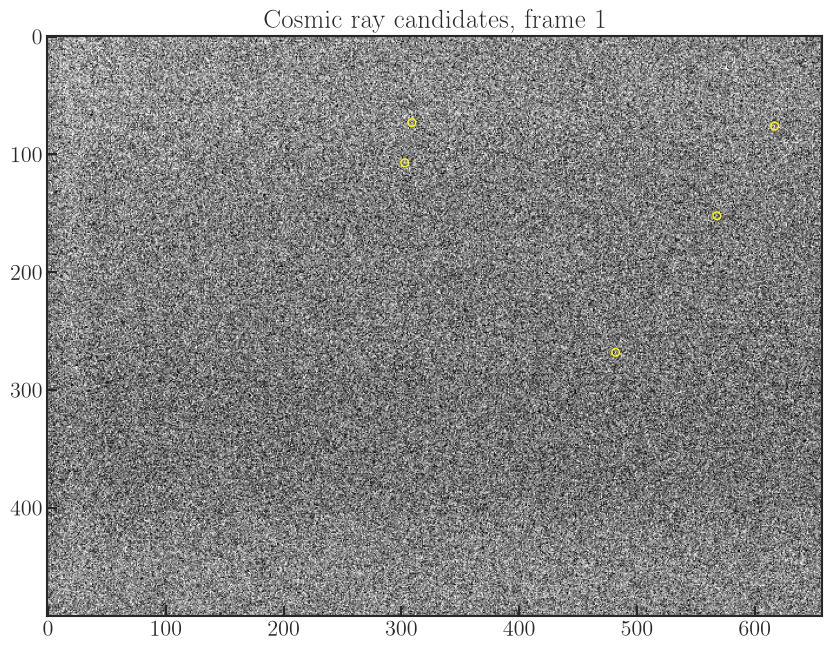

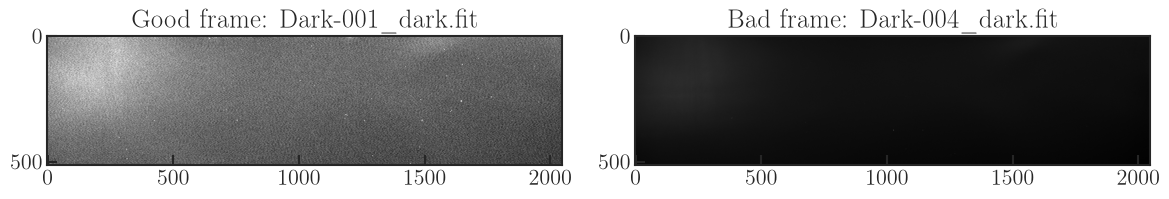

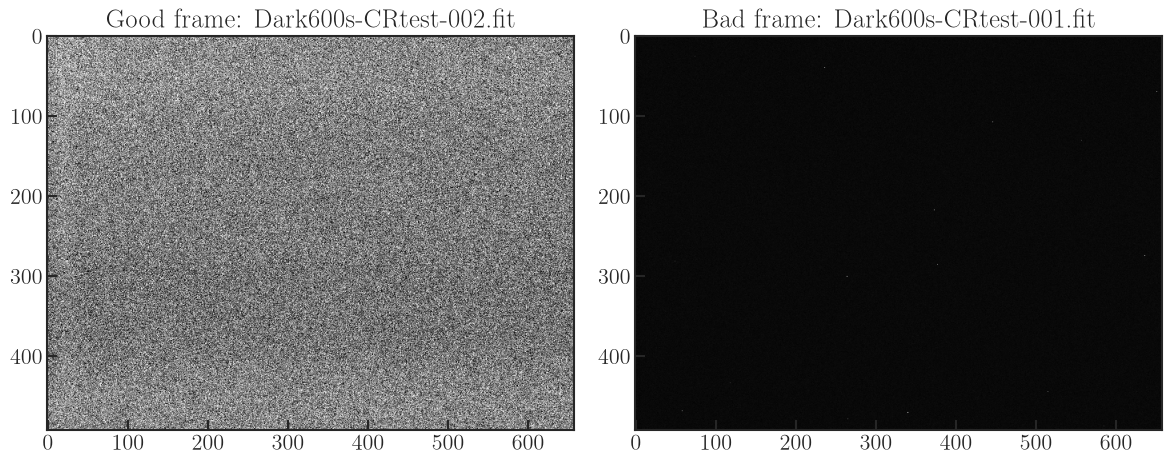

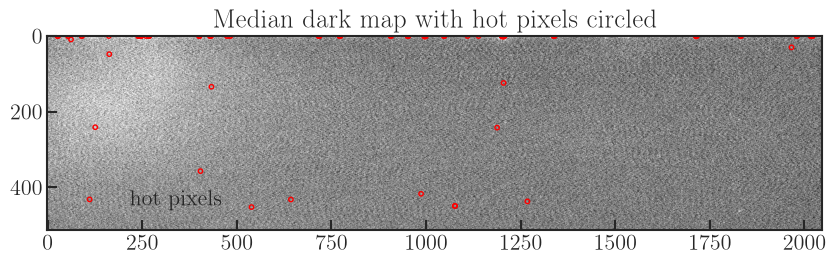

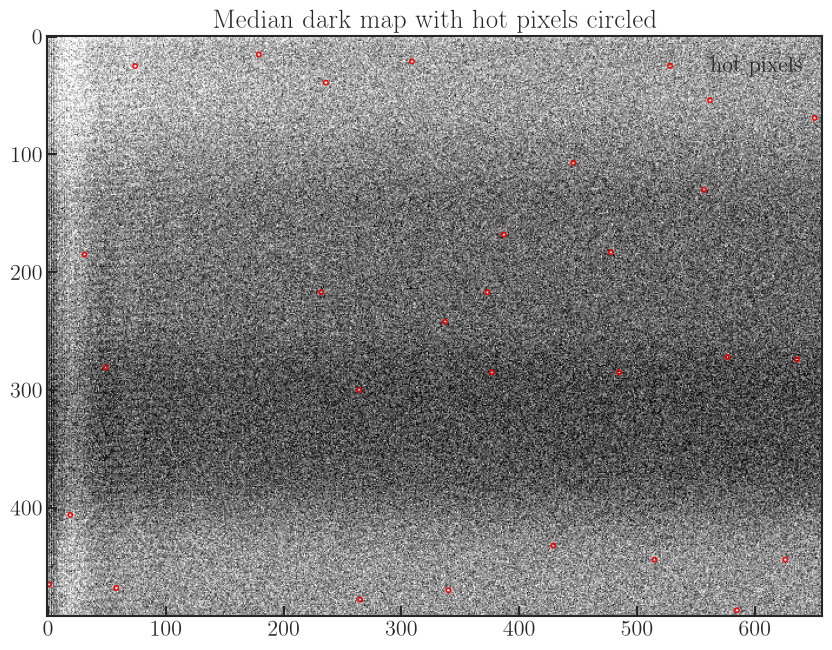

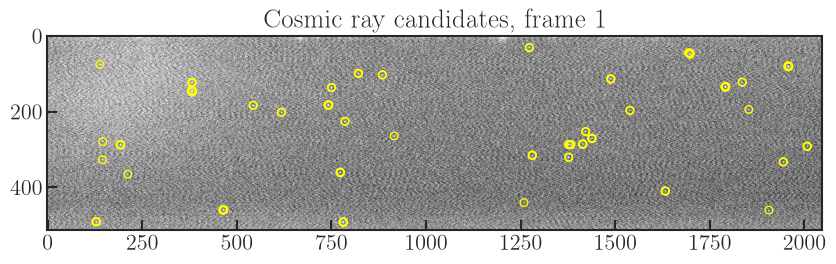

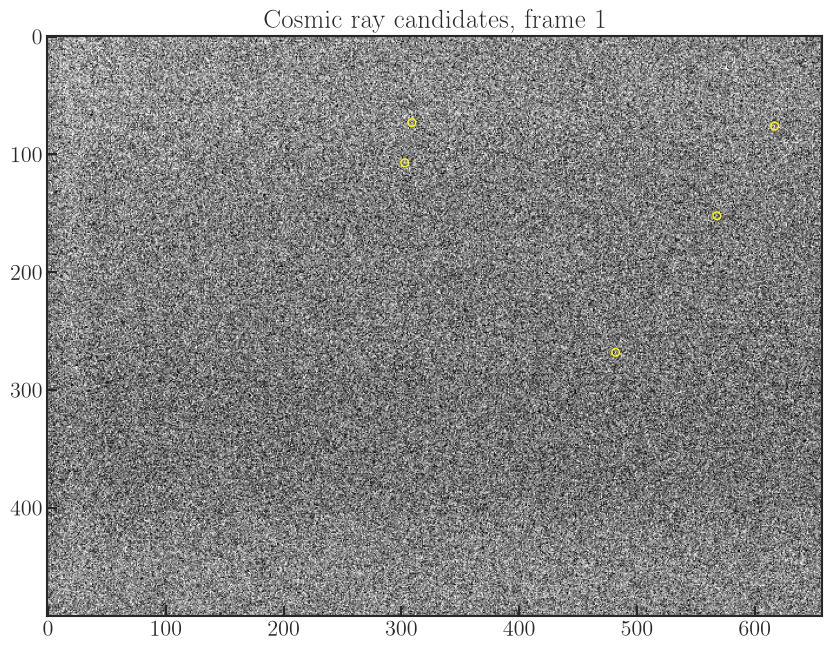

In [76]:
import cosmic_rays as cs
importlib.reload(cs)

andor_results = cs.full_analyze("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays/")
atik_results = cs.full_analyze("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/CRtest")